# OLIST MARKETING ANALYTICS - FULL PYTHON ANALYSIS 


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

sns.set_style("whitegrid")


## 0. LOAD & BUILD FEATURE BASE ##


In [0]:
orders=spark.table("workspace.default.olist_orders_dataset").toPandas()
customers=spark.table("workspace.default.olist_customers_dataset").toPandas()
products=spark.table("workspace.default.olist_products_dataset").toPandas()
order_items=spark.table("workspace.default.olist_order_items_dataset").toPandas()
payments=spark.table("workspace.default.olist_order_payments_dataset").toPandas()
reviews=spark.table("workspace.default.olist_order_reviews_dataset").toPandas()
cat_trans=spark.table("workspace.default.product_category_name_translation").toPandas()





In [0]:
products=products.merge(cat_trans,on="product_category_name",how="left")
products["product_category_name_english"]=products["product_category_name_english"].fillna("Uncategorized")
items_agg=order_items.groupby("order_id").agg(total_price=("price","sum"),total_freight=("freight_value","sum"),n_items=("order_item_id","count")).reset_index()
first_item=order_items.sort_values("order_item_id").groupby("order_id").first().reset_index()
first_item=first_item.merge(products[["product_id","product_category_name_english"]],on="product_id",how="left")
pay_agg=payments.groupby("order_id").agg(total_payment=("payment_value","sum"),max_installments=("payment_installments","max")).reset_index()
pay_type=payments.sort_values("payment_sequential").groupby("order_id").first()[["payment_type"]].reset_index()
rev_agg=reviews.groupby("order_id").agg(review_score=("review_score","max")).reset_index()
orders_c=orders.merge(customers,on="customer_id",how="left")

base = (orders_c.merge(items_agg, on="order_id", how="left") 
               .merge(first_item[["order_id","product_category_name_english"]], on="order_id", how="left") 
               .merge(pay_agg, on="order_id", how="left") 
               .merge(pay_type, on="order_id", how="left") 
               .merge(rev_agg, on="order_id", how="left"))
base["order_revenue"] = base["total_price"] + base["total_freight"]
base["is_late"] = (base["order_delivered_customer_date"] > base["order_estimated_delivery_date"]).astype(int)
base["is_low_review"] = (base["review_score"] <= 2).astype(int)
base["delivery_delay_days"] = (base["order_delivered_customer_date"] - base["order_estimated_delivery_date"]).dt.days
base["order_month"] = base["order_purchase_timestamp"].dt.to_period("M").astype(str)
base["order_month_num"] = base["order_purchase_timestamp"].dt.month
base["order_dow"] = base["order_purchase_timestamp"].dt.day_name()
base["order_dow_num"] = base["order_purchase_timestamp"].dt.dayofweek
base_full = base.copy()  # keep full version before excluding tail, for reference
base = base[base["order_purchase_timestamp"] < "2018-09-01"].copy()  # exclude incomplete collection-cutoff tail
print("Base shape (tail excluded):", base.shape)
 
results = {}  # collect key findings for a final summary print

Base shape (tail excluded): (99421, 28)


**Insight:** The analysis base contains **99,421 orders** placed between Sep 2016 and Aug 2018. The final collection month (Sep - Oct 2018) was deliberately excluded - it contains only ~20 orders total and would distort any trend or seasonality read as a false "collapse" at the end of the dataset.

### SECTION 1: DESCRIPTIVE ANALYSIS


### 1.1 Sales & Revenue by Order Status


--- Sales & Revenue by Status ---
               orders      revenue
order_status                     
delivered      96478  15419773.75
shipped         1106    176962.88
canceled         606    105885.72
processing       301     69394.11
invoiced         314     68988.75
unavailable      609      2140.49
approved           2       241.08
created            5         0.00


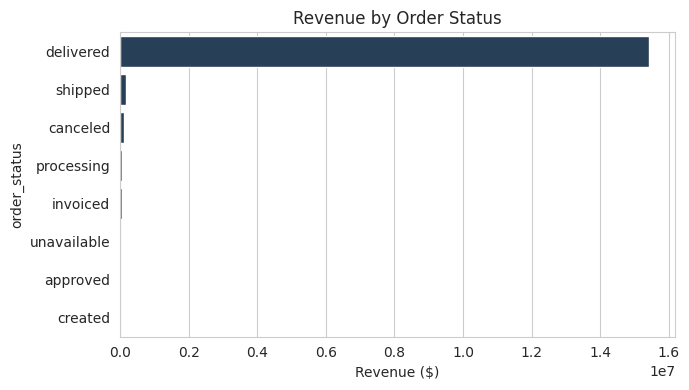

In [0]:
b1=base.groupby("order_status").agg(orders=("order_id","nunique"),revenue=("order_revenue","sum")).sort_values("revenue",ascending=False)
print("\n--- Sales & Revenue by Status ---\n",b1)
results["total_revenue"]=base["order_revenue"].sum()
results["total_orders"]=base["order_id"].nunique()

plt.figure(figsize=(7,4))
sns.barplot(x=b1["revenue"], y=b1.index, color="#1F3F5F")
plt.title("Revenue by Order Status")
plt.xlabel("Revenue ($)")
plt.tight_layout()
plt.show()



**Finding:** 96.5% of orders (95,478) reached delivered status, generating $15.42M - 97% of all revenue. Canceled orders (606, 0.6%) represent lost potential revenue. shipped, processing, and invoiced orders together (~1,221 orders) are still mid-flight and represent revenue not yet realized.
**Marketing implication:** The order-status funnel is healthy - the ~3% of orders that don't reach delivery is a small.

### 1.2 Temporal Pattern - Orders by Month

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
Name: order_id, dtype: int64


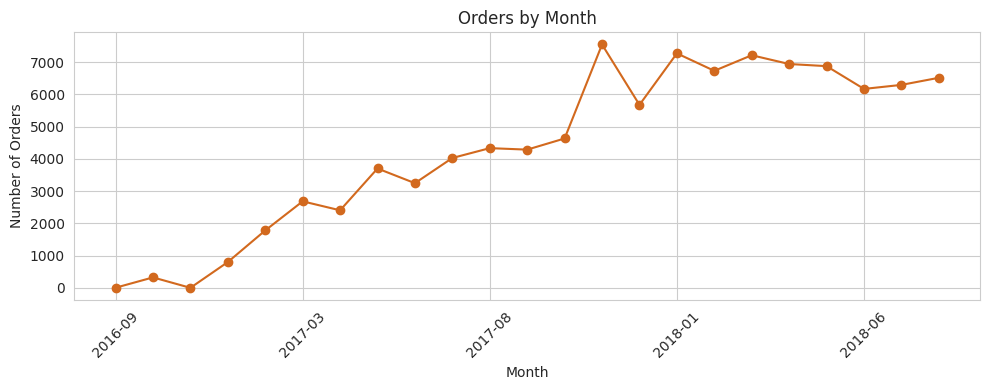

In [0]:
b3 = base.groupby("order_month")["order_id"].nunique()
print(b3)

plt.figure(figsize=(10,4))
b3.plot(
    kind="line",
    marker="o",
    color="#D2691E"
)

plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Finding:** Order volume grows steadily from launch (Sep 2016) through 2018, with a sharp spike in **November 2017 (7,544 orders)** - Brazil's Black Friday. This single month is ~27% above the surrounding 3-month average.

**Marketing implication:** Seasonal campaigns clearly move volume - worth planning inventory and marketing spend around November specifically, and testing whether a similar push works in other months.

### 1.3 Product & Category Performance - Top 10 Categories by Revenue


--- Top 10 Categories by Revenue ---
 product_category_name_english
health_beauty            1439976.57
watches_gifts            1303063.90
bed_bath_table           1240295.97
sports_leisure           1157653.73
computers_accessories    1057507.38
furniture_decor           906457.18
housewares                780685.76
cool_stuff                720551.07
auto                      685286.34
garden_tools              584316.50
Name: order_revenue, dtype: float64


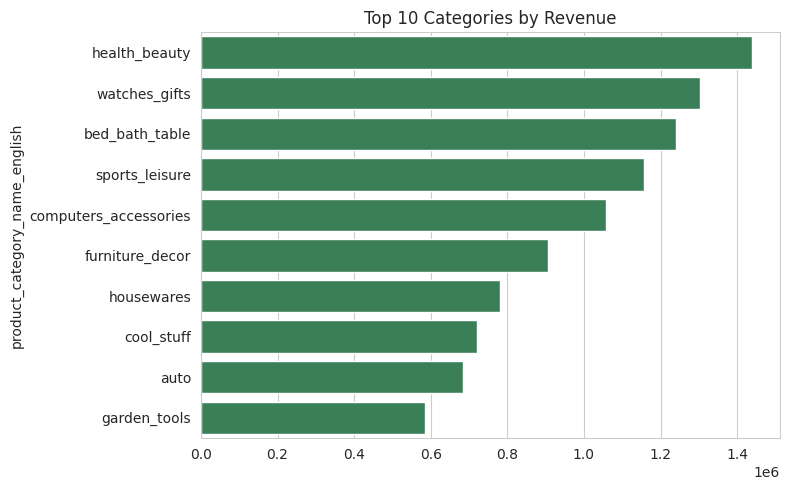

In [0]:
b4=base.groupby("product_category_name_english")["order_revenue"].sum().sort_values(ascending=False).head(10)
print("\n--- Top 10 Categories by Revenue ---\n", b4)
plt.figure(figsize=(8,5))
sns.barplot(x=b4.values, y=b4.index, color="#2E8B57")
plt.title("Top 10 Categories by Revenue");
plt.tight_layout()
plt.show()

**Finding:** health_beauty is the top revenue category (R$1.44M), narrowly ahead of watches_gifts (R$1.30M) and bed_bath_table (R$1.24M). The top 3 categories are close together - no single category dominates the way "SP dominates by state" does.

**Marketing implication:** Category investment can be spread across 3–4 strong performers rather than betting everything on one "hero" category.

### 1.4 Customer Satisfaction - Review Score Distribution

--- Review Score Distribution (%) ---
review_score
1.0    11.459241
2.0     3.159527
3.0     8.225718
4.0    19.302816
5.0    57.852697
Name: proportion, dtype: float64


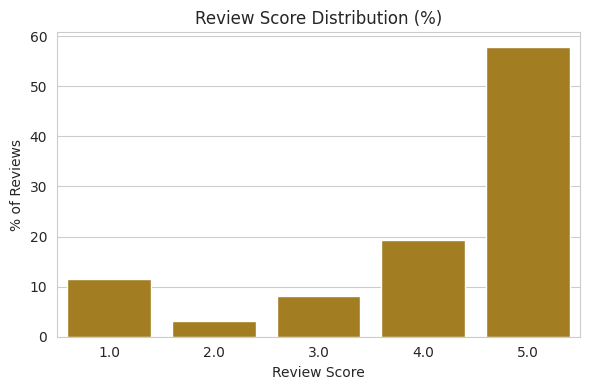

In [0]:
b5 = base["review_score"].value_counts(normalize=True).sort_index() * 100
print("--- Review Score Distribution (%) ---")
print(b5)
results["avg_review_score"] = base["review_score"].mean()
plt.figure(figsize=(6,4))
sns.barplot(x=b5.index, y=b5.values, color="#B8860B")
plt.title("Review Score Distribution (%)")
plt.xlabel("Review Score")
plt.ylabel("% of Reviews")
plt.tight_layout()
plt.show()

**Finding:** 57.9% of reviews are 5-star, but **14.6% are 1 - 2 star** (detractors) - a meaningful minority. Average review score is 4.09.

**Marketing implication:** A 14.6% detractor rate is large enough to actively suppress word-of-mouth and repeat purchase.

### 1.5 Delivery Experience

--- Delivery ---
Avg delivery delay (days, negative=early): -11.88
Late delivery rate: 7.87 %


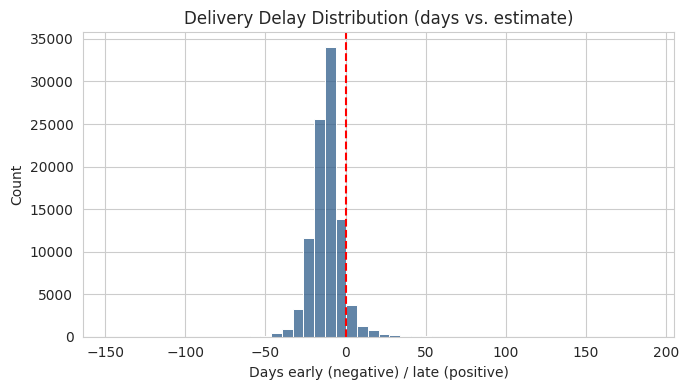

In [0]:
print("--- Delivery ---")
avg_delay = base["delivery_delay_days"].mean()
late_rate = base["is_late"].mean() * 100
print("Avg delivery delay (days, negative=early):", round(avg_delay,2))
print("Late delivery rate:", round(late_rate,2), "%")
results["late_delivery_rate"] = late_rate
plt.figure(figsize=(7,4))
sns.histplot(base["delivery_delay_days"].dropna(), bins=50, color="#2E5C8A")
plt.axvline(0, color="red", linestyle="--")
plt.title("Delivery Delay Distribution (days vs. estimate)")
plt.xlabel("Days early (negative) / late (positive)")
plt.tight_layout()
plt.show()

**Finding:** On average, orders arrive **11.88 days earlier** than the estimated delivery date - Olist's estimates are heavily padded. Still, **7.87% of orders arrive late**, which is the segment driving the satisfaction problem.

**Marketing implication:** The estimate itself may be a lever - tighter, more honest estimates could reduce the "pleasant surprise" that most customers get, but more importantly, that 7.87% late group needs proactive service recovery.

### 1.6 Payment Behavior - Payment Type Mix

--- Payment Type Mix (%) ---
payment_type
credit_card    76.950312
boleto         19.899417
voucher         1.611346
debit_card      1.536914
not_defined     0.002012
Name: proportion, dtype: float64


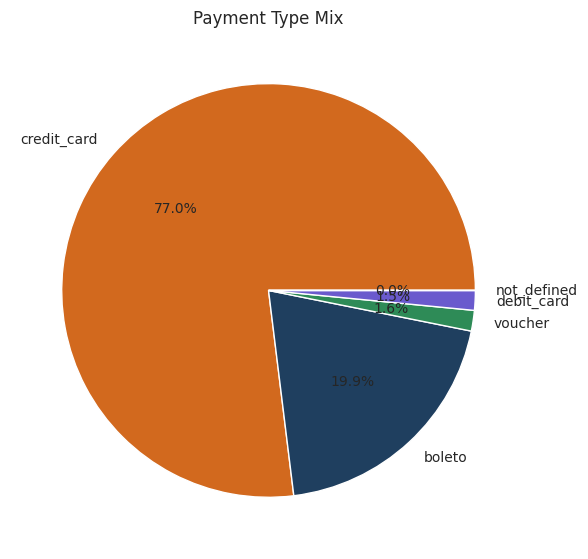

In [0]:
b7 = base["payment_type"].value_counts(normalize=True) * 100
print("--- Payment Type Mix (%) ---")
print(b7)
plt.figure(figsize=(6,6))
plt.pie(b7.values, labels=b7.index, autopct="%1.1f%%", colors=["#D2691E","#1F3F5F","#2E8B57","#6A5ACD","#B8860B"])
plt.title("Payment Type Mix")
plt.tight_layout()
plt.show()

**Finding:** Credit card dominates at 77% of orders, followed by boleto (Brazil's bank-slip payment method) at 19.9%. Voucher and debit card are minor (1.6% and 1.5% respectively).

**Marketing implication:** Given credit card's dominance, installment-based promotions are the more relevant lever than payment-method-specific campaigns.

### SECTION 2: DIAGNOSTIC ANALYSIS

### 2.1 Does Late Delivery Hurt Review Scores?


--- Avg Review Score: On-Time vs Late ---
 On-Time    4.217294
Late       2.569303
Name: review_score, dtype: float64


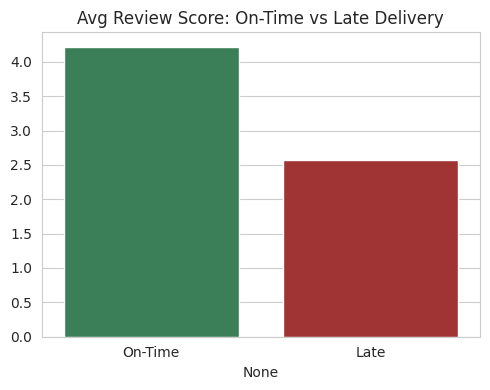

In [0]:
c1=base.dropna(subset=["is_late","review_score"]).groupby("is_late")["review_score"].mean()
c1.index=["On-Time","Late"]
print("\n--- Avg Review Score: On-Time vs Late ---\n", c1)
plt.figure(figsize=(5,4))
sns.barplot(x=c1.index,y=c1.values,palette=["#2E8B57","#B22222"])
plt.title("Avg Review Score: On-Time vs Late Delivery")
plt.tight_layout()
plt.show()


**Finding:** On-time orders average **4.22 stars**; late orders average **2.57 stars** - a 1.65-star gap. This is the single strongest satisfaction driver found in the entire analysis.

**Marketing implication:** Delivery reliability isn't just an operations metric - it's directly a marketing/retention lever. Any investment in reducing the 7.87% late-delivery rate pays back through satisfaction and, downstream, retention.

### 2.2 Category Quality Map - Volume vs Satisfaction

--- Category Volume vs Avg Review Score (Top 15) ---
                               orders  avg_score
product_category_name_english                   
bed_bath_table                   9207   3.987835
health_beauty                    8731   4.188180
sports_leisure                   7630   4.173657
computers_accessories            6620   4.032326
furniture_decor                  6305   4.029025
housewares                       5789   4.153049
watches_gifts                    5554   4.071840
telephony                        4151   4.006986
auto                             3860   4.097409
toys                             3828   4.192268
cool_stuff                       3570   4.180672
garden_tools                     3461   4.151112
perfumery                        3137   4.210073
baby                             2815   4.056128
electronics                      2521   4.099167


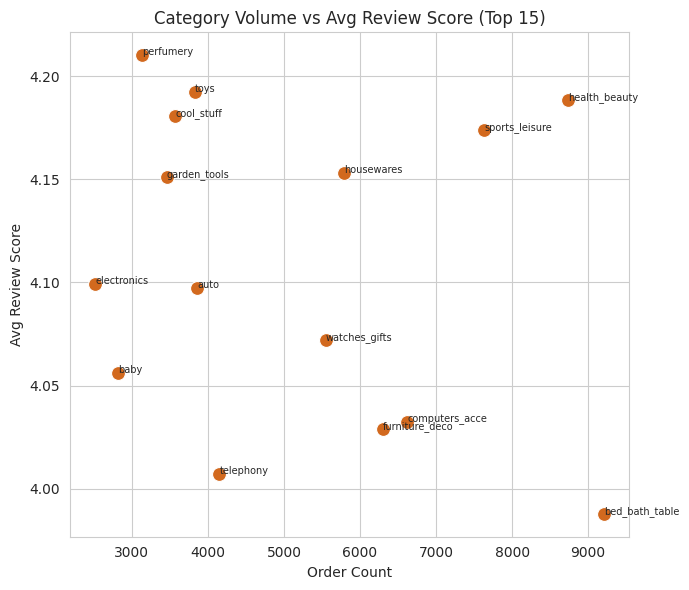

In [0]:
c2 = base.dropna(subset=["review_score"]).groupby("product_category_name_english").agg(orders=("order_id","nunique"), avg_score=("review_score","mean")).sort_values("orders", ascending=False).head(15)
print("--- Category Volume vs Avg Review Score (Top 15) ---")
print(c2)
plt.figure(figsize=(7,6))
sns.scatterplot(data=c2, x="orders", y="avg_score", s=100, color="#D2691E")
for cat, row in c2.iterrows():plt.annotate(cat[:14], (row["orders"], row["avg_score"]), fontsize=7)
plt.title("Category Volume vs Avg Review Score (Top 15)")
plt.xlabel("Order Count")
plt.ylabel("Avg Review Score")
plt.tight_layout()
plt.show()

**Finding:** bed_bath_table has the **highest order volume** (9,207 orders) among top categories but the **lowest average score** (3.99) of the group - a genuine quality/expectation gap despite being a top seller. perfumery and toys score highest (~4.19 - 4.21) at much lower volume.

**Marketing implication:** bed_bath_table is a volume leader with a satisfaction problem - worth root-causing (product quality? Shipping damage? Size/fit mismatch?) before scaling further marketing spend into it.

### 2.3 Which States Show Low Satisfaction Not Explained by Delay?


--- Lowest-Satisfaction States ---
                 avg_delay  avg_score  orders
customer_state                              
MA              -9.650281   3.834270     712
AL              -8.817259   3.857868     394
SE             -10.068862   3.907186     334
PA             -14.190782   3.914255     933
BA             -10.896562   3.931867    3229
CE             -10.854674   3.944226    1273
RJ             -11.826183   3.967251   12214
PI             -11.295117   3.993631     471
PB             -13.447266   4.076172     512
ES             -10.682580   4.080752    1969


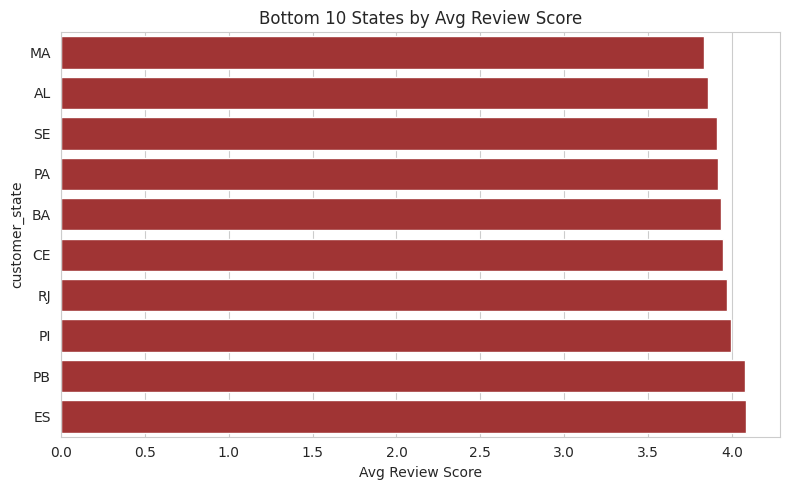

In [0]:
c3 = base.dropna(subset=["review_score","delivery_delay_days"]).groupby("customer_state").agg(
    avg_delay=("delivery_delay_days","mean"), avg_score=("review_score","mean"), orders=("order_id","nunique"))
c3 = c3[c3["orders"]>200].sort_values("avg_score")
print("\n--- Lowest-Satisfaction States ---\n", c3.head(10))

plt.figure(figsize=(8,5))
sns.barplot(x=c3.head(10)["avg_score"], y=c3.head(10).index, color="#B22222")
plt.title("Bottom 10 States by Avg Review Score")
plt.xlabel("Avg Review Score")
plt.tight_layout()
plt.show()

**Finding:** MA has the lowest average score (3.83) despite only moderate delay (-9.65 days - not the worst). PA has the largest early-arrival margin (-14.19 days) yet isn't the lowest-scoring state. **Satisfaction gaps are not purely explained by delivery timing.

**Marketing implication:** Something state-specific beyond delivery speed is driving dissatisfaction in MA, AL, and SE - possibly product fit, regional service expectations, or seller mix. Worth a qualitative review of comments from these states specifically.

### 2.4 Why Do Customers Never Place a Second Order?

In [0]:
cust_counts = base.groupby("customer_unique_id")["order_id"].nunique().reset_index(name="order_count")
first_orders = base.sort_values("order_purchase_timestamp").groupby("customer_unique_id").first().reset_index()
first_orders = first_orders.merge(cust_counts, on="customer_unique_id")
first_orders["customer_type"] = np.where(first_orders["order_count"]>1, "Repeat","One-Time")
c4 = first_orders.groupby("customer_type").agg(
    avg_first_review=("review_score","mean"), avg_first_delay=("delivery_delay_days","mean"), n=("customer_unique_id","count"))
print("\n--- First-Order Attributes: One-Time vs Repeat ---\n", c4)


--- First-Order Attributes: One-Time vs Repeat ---
                avg_first_review  avg_first_delay      n
customer_type                                          
One-Time               4.084213       -11.825600  93103
Repeat                 4.147079       -12.705585   2987


**Finding (counter-intuitive):** Customers who went on to become repeat buyers actually had a slightly **better** first-order review score 
(4.15 vs 4.08) and a similar delivery experience compared to one-time customers. A bad first experience is NOT the primary churn driver.

****Marketing implication:** This changes how we should look at the retention problem. Fixing delivery and product quality issues alone may not reduce the 97%+ one-time purchase rate by much. The main reason could be that many customers only planned to buy once, do not have a strong reason to return, or are not encouraged through loyalty programs. Therefore, the retention strategy should focus on giving customers a reason to come back, such as loyalty rewards, discounts, and suggesting products from other categories.


### 2.5 Does Installment Count Affect Order Value or Cancellation Risk?


--- Installments vs Order Value & Cancellation ---
                    avg_value  cancel_rate      n
max_installments                                
1.0               120.563072     0.630078  48248
2.0               129.041436     0.485319  12363
3.0               144.319267     0.661617  10429
4.0               164.972682     0.594059   7070
5.0               185.019169     0.573943   5227
6.0               211.325626     0.562948   3908
7.0               188.845574     0.369914   1622
8.0               309.657640     0.682192   4251
9.0               199.592504     0.931677    644
10.0              416.435797     0.677328   5315
12.0              319.576336     0.000000    133
15.0              446.400541     0.000000     74


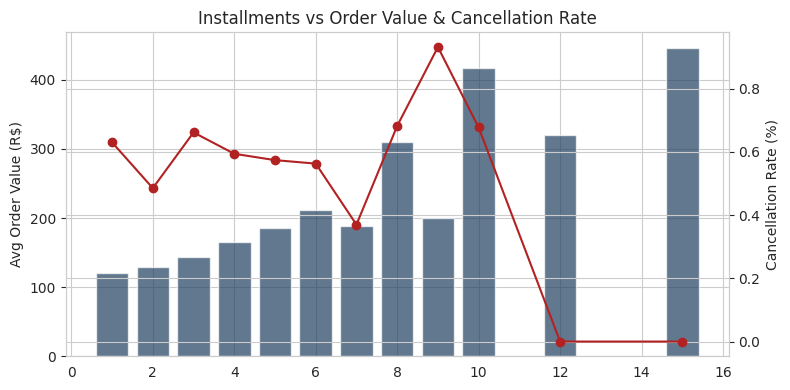

In [0]:
c5 = base.dropna(subset=["max_installments"]).groupby("max_installments").agg(
    avg_value=("order_revenue","mean"), cancel_rate=("order_status", lambda x: (x=="canceled").mean()*100), n=("order_id","count"))
c5 = c5[c5["n"]>50]
print("\n--- Installments vs Order Value & Cancellation ---\n", c5)
fig, ax1 = plt.subplots(figsize=(8,4))
ax1.bar(c5.index, c5["avg_value"], color="#1F3F5F", alpha=0.7)
ax1.set_ylabel("Avg Order Value (R$)")
ax2 = ax1.twinx()
ax2.plot(c5.index, c5["cancel_rate"], color="#B22222", marker="o")
ax2.set_ylabel("Cancellation Rate (%)")
plt.title("Installments vs Order Value & Cancellation Rate")
plt.tight_layout()
plt.show()

**Finding:** Higher installment counts correlate clearly with higher order value - R$120.56 at 1 installment vs. R$211.33 at 6 installments. Cancellation rate stays consistently low (~0.4–0.7%) across all installment tiers, showing no installment-driven cancellation risk.

**Marketing implication:** Installment options are a legitimate lever for increasing basket size, not a risk factor - promoting "pay in 6x" style messaging on higher-value categories could lift AOV without adding cancellation risk.



### 2.6 Do High-Freight-Ratio Categories Suppress Volume?


--- Highest Freight-to-Price Ratio Categories ---
                                    orders  avg_freight_ratio
product_category_name_english                               
home_comfort_2                         24           0.933862
dvds_blu_ray                           59           0.833045
electronics                          2550           0.683517
christmas_supplies                    128           0.675660
fashion_underwear_beach               121           0.565503
flowers                                29           0.564979
signaling_and_security                140           0.546211
telephony                            4199           0.505945
food_drink                            227           0.498291
furniture_mattress_and_upholstery      38           0.488798


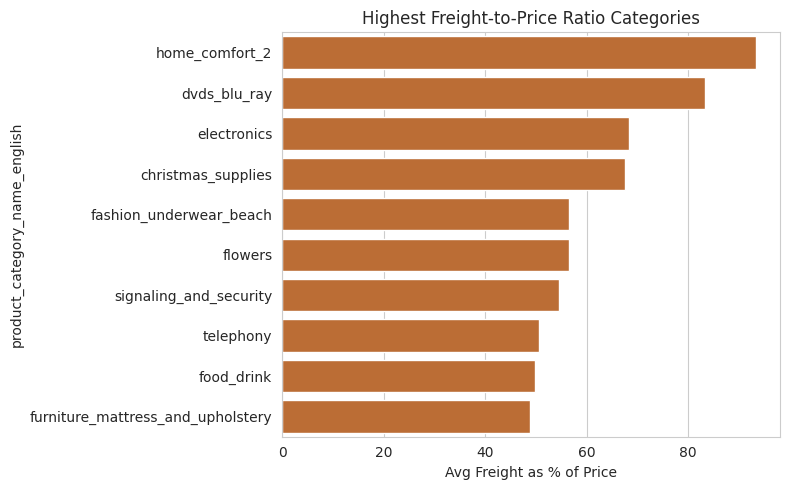

In [0]:
oi_prod = order_items.merge(products[["product_id","product_category_name_english"]], on="product_id", how="left")
oi_prod["freight_ratio"] = oi_prod["freight_value"] / oi_prod["price"].replace(0,np.nan)
c6 = oi_prod.groupby("product_category_name_english").agg(orders=("order_id","nunique"), avg_freight_ratio=("freight_ratio","mean")).sort_values("avg_freight_ratio", ascending=False).head(10)
print("\n--- Highest Freight-to-Price Ratio Categories ---\n", c6)

plt.figure(figsize=(8,5))
sns.barplot(x=c6["avg_freight_ratio"]*100, y=c6.index, color="#D2691E")
plt.title("Highest Freight-to-Price Ratio Categories")
plt.xlabel("Avg Freight as % of Price")
plt.tight_layout()
plt.show()

**Finding:** home_comfort_2 and dvds_blu_ray have freight costs averaging **83 - 93% of the item price** - nearly doubling the effective cost. electronics sits at 68%. These are also relatively low-volume categories.

**Marketing implication:** These categories are strong candidates for a free-shipping-threshold promotion - the freight cost is likely a real barrier to conversion, not just an operational detail.

## SECTION 3: DEEP-DIVE MARKETING ANALYTICS

### D1. RFM SEGMENTATION 


--- D1. RFM Segmentation ---
               customers  avg_monetary
rfm_segment                           
New/Promising      38200    164.494505
Lost/Churned       36903    162.775156
Regular            20108    151.287056
Champions            135    177.952694
At-Risk Loyal         74    137.926261
NOTE: Frequency is heavily skewed (most customers order once) — F-score bins are coarse by design.


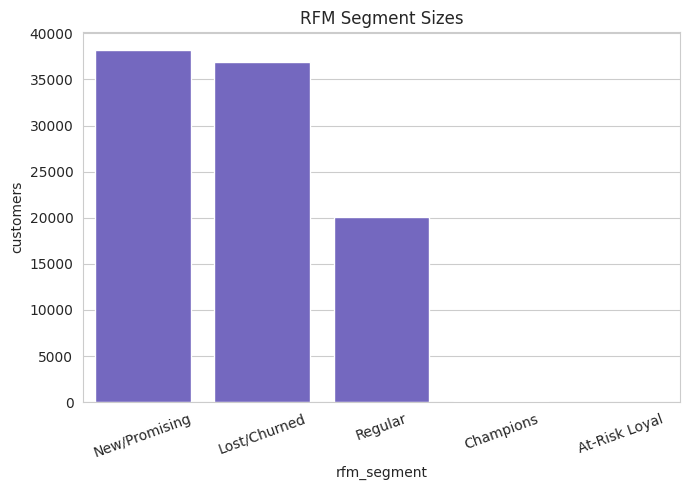

In [0]:
print("\n--- D1. RFM Segmentation ---")
snapshot_date = base["order_purchase_timestamp"].max()
rfm = base.groupby("customer_unique_id").agg(
    recency_days=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id","nunique"),
    monetary=("order_revenue","mean")
).reset_index()
 
rfm = rfm.dropna(subset=["monetary"]).copy()  # some orders have no matched order_items (e.g. unavailable/created status), drop those customers from RFM
rfm["r_score"] = pd.qcut(rfm["recency_days"], 5, labels=[5,4,3,2,1], duplicates="drop").astype(int)  # lower recency_days = more recent = higher score
rfm["f_score"] = pd.cut(rfm["frequency"], bins=[0,1,2,100], labels=[1,3,5]).astype(int)  # frequency mostly 1 vs 2+, so coarse bins
rfm["m_score"] = pd.qcut(rfm["monetary"], 5, labels=[1,2,3,4,5], duplicates="drop").astype(int)
 
def segment(row):
    if row["r_score"]>=4 and row["f_score"]>=4: return "Champions"
    if row["r_score"]>=4 and row["f_score"]<4: return "New/Promising"
    if row["r_score"]<3 and row["f_score"]>=4: return "At-Risk Loyal"
    if row["r_score"]<3 and row["f_score"]<3: return "Lost/Churned"
    return "Regular"
rfm["rfm_segment"] = rfm.apply(segment, axis=1)
 
seg_summary = rfm.groupby("rfm_segment").agg(customers=("customer_unique_id","count"), avg_monetary=("monetary","mean")).sort_values("customers", ascending=False)
print(seg_summary)
print("NOTE: Frequency is heavily skewed (most customers order once) — F-score bins are coarse by design.")
 
plt.figure(figsize=(7,5))
sns.barplot(x=seg_summary.index, y=seg_summary["customers"], color="#6A5ACD")
plt.title("RFM Segment Sizes"); plt.xticks(rotation=20); plt.tight_layout();plt.show()

**Finding:** Champions is a tiny segment (135 customers) compared to "Lost/Churned" (36,903) and "New/Promising" (38,200) - a direct reflection of the ~3% overall repeat rate. Manual RFM bucketing is limited here because Frequency barely varies (see K-Means clustering in 3.8 for a richer segmentation that overcomes this).

**Marketing implication:** Broad-based acquisition-to-retention conversion matters more than "protecting a VIP tier" - there simply isn't a large loyal tier yet to protect.

### D2. CUSTOMER LIFETIME VALUE (revenue-based proxy) 


--- D2. Customer Lifetime Value (revenue proxy) ---
count    96090.000000
mean       164.880703
std        227.941407
min          0.000000
25%         62.390000
50%        107.275000
75%        182.252500
max      13664.080000
Name: lifetime_revenue, dtype: float64
Top 10% of customers by revenue drive 38.5% of total revenue


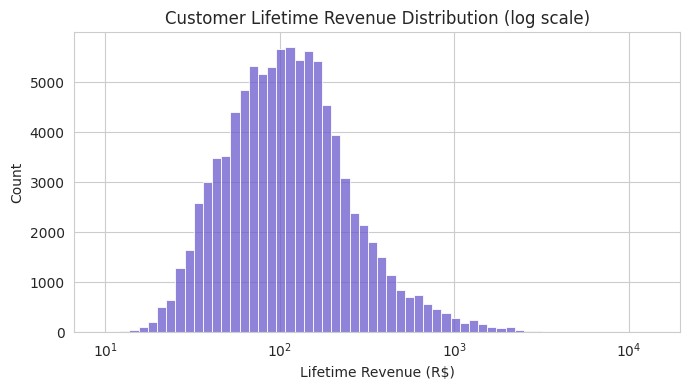

In [0]:
print("\n--- D2. Customer Lifetime Value (revenue proxy) ---")
clv = base.groupby("customer_unique_id").agg(total_orders=("order_id","nunique"), lifetime_revenue=("order_revenue","sum")).reset_index()
print(clv["lifetime_revenue"].describe())
top10pct_cutoff = clv["lifetime_revenue"].quantile(0.90)
top10pct_share = clv[clv["lifetime_revenue"]>=top10pct_cutoff]["lifetime_revenue"].sum() / clv["lifetime_revenue"].sum() * 100
print(f"Top 10% of customers by revenue drive {round(top10pct_share,1)}% of total revenue")

plt.figure(figsize=(7,4))
sns.histplot(clv["lifetime_revenue"].dropna(), bins=60, color="#6A5ACD", log_scale=(True,False))
plt.title("Customer Lifetime Revenue Distribution (log scale)")
plt.xlabel("Lifetime Revenue (R$)")
plt.tight_layout()
plt.show()

*(Note: this is a revenue-based CLV proxy - no cost/margin data is available in this dataset, so it should not be read as true profit-based CLV.)*

**Finding:** Top 10% of customers drive **38.5%** of total revenue - a real but moderate concentration, notably less extreme than a classic 80/20 pattern.

**Marketing implication:** There's no small "whale" segment to lean on disproportionately - retention and growth strategy needs to be broad-based across the customer base rather than narrowly VIP-focused.

### D3. COHORT RETENTION ANALYSIS

In [0]:
print("--- D3. Cohort Retention (first 6 months after acquisition) ---")first_order_month = base.groupby("customer_unique_id")["order_purchase_timestamp"].min().dt.to_period("M")cohort_df = base[["customer_unique_id","order_purchase_timestamp"]].copy()cohort_df["cohort_month"] = cohort_df["customer_unique_id"].map(first_order_month)cohort_df["order_month_p"] = cohort_df["order_purchase_timestamp"].dt.to_period("M")cohort_df["month_number"] = (cohort_df["order_month_p"] - cohort_df["cohort_month"]).apply(lambda x: x.n)cohort_counts = cohort_df.groupby(["cohort_month","month_number"])["customer_unique_id"].nunique().reset_index()cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="month_number", values="customer_unique_id")cohort_size = cohort_pivot[0]retention = cohort_pivot.divide(cohort_size, axis=0) * 100print("Retention % by cohort month (columns = months since acquisition):")print(retention.iloc[:, :4].round(2))plt.figure(figsize=(10,7))sns.heatmap(retention.iloc[:,:6], annot=True, fmt=".1f", cmap="YlOrRd_r", cbar_kws={"label":"Retention %"})plt.title("Cohort Retention Heatmap (% active by months since acquisition)")plt.xlabel("Months Since First Order")plt.ylabel("Acquisition Cohort")plt.tight_layout()plt.show()


--- D3. Cohort Retention (first 3 months after acquisition) ---
Retention % by cohort month (columns = months since acquisition):
month_number      0       1     2     3
cohort_month                           
2016-09       100.0     NaN   NaN   NaN
2016-10       100.0     NaN   NaN   NaN
2016-12       100.0  100.00   NaN   NaN
2017-01       100.0    0.39  0.26  0.13
2017-02       100.0    0.23  0.29  0.11
2017-03       100.0    0.49  0.38  0.38
2017-04       100.0    0.60  0.21  0.17
2017-05       100.0    0.50  0.50  0.39
2017-06       100.0    0.48  0.35  0.41
2017-07       100.0    0.51  0.36  0.26
2017-08       100.0    0.69  0.33  0.26
2017-09       100.0    0.68  0.53  0.29
2017-10       100.0    0.69  0.25  0.09
2017-11       100.0    0.55  0.38  0.18
2017-12       100.0    0.26  0.27  0.35
2018-01       100.0    0.34  0.38  0.28
2018-02       100.0    0.39  0.39  0.29
2018-03       100.0    0.46  0.32  0.29
2018-04       100.0    0.58  0.31  0.24
2018-05       100.0    0.53  

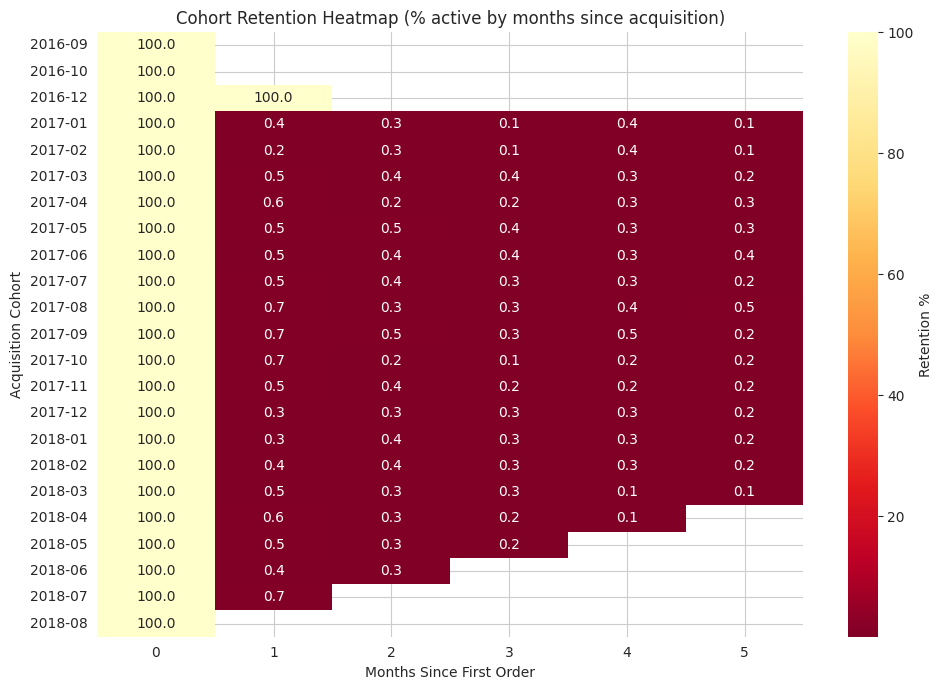

In [0]:
print("\n--- D3. Cohort Retention (first 3 months after acquisition) ---")
first_order_month = base.groupby("customer_unique_id")["order_purchase_timestamp"].min().dt.to_period("M")
cohort_df = base[["customer_unique_id","order_purchase_timestamp"]].copy()
cohort_df["cohort_month"] = cohort_df["customer_unique_id"].map(first_order_month)
cohort_df["order_month_p"] = cohort_df["order_purchase_timestamp"].dt.to_period("M")
cohort_df["month_number"] = (cohort_df["order_month_p"] - cohort_df["cohort_month"]).apply(lambda x: x.n)

cohort_counts = cohort_df.groupby(["cohort_month","month_number"])["customer_unique_id"].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index="cohort_month", columns="month_number", values="customer_unique_id")
cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100
print("Retention % by cohort month (columns = months since acquisition):")
print(retention.iloc[:, :4].round(2))  # first 4 months only for readability

plt.figure(figsize=(10,7))
sns.heatmap(retention.iloc[:,:6], annot=True, fmt=".1f", cmap="YlOrRd_r", cbar_kws={"label":"Retention %"})
plt.title("Cohort Retention Heatmap (% active by months since acquisition)")
plt.xlabel("Months Since First Order")
plt.ylabel("Acquisition Cohort")
plt.tight_layout()
plt.show()
 

**Finding:** Month-1 retention is frequently **below 1%** across almost every cohort - this is a far more dramatic visual than the flat "3% repeat rate" KPI alone. Churn happens almost immediately after the first purchase, not gradually over time.

**Marketing implication:** Any retention intervention (email, loyalty offer, remarketing) needs to happen in the first few weeks post-purchase - waiting even one month is too late for most customers.

### D4. REVENUE CONCENTRATION / PARETO 


--- D4. Revenue Concentration by State (Pareto) ---
                   revenue  cumulative_pct
customer_state                            
SP              5921511.66       37.375289
RJ              2129681.98       50.817377
MG              1856161.49       62.533064
RS               885826.76       68.124209
PR               800935.44       73.179539
BA               611506.67       77.039235
SC               610213.60       80.890770
DF               353229.44       83.120277


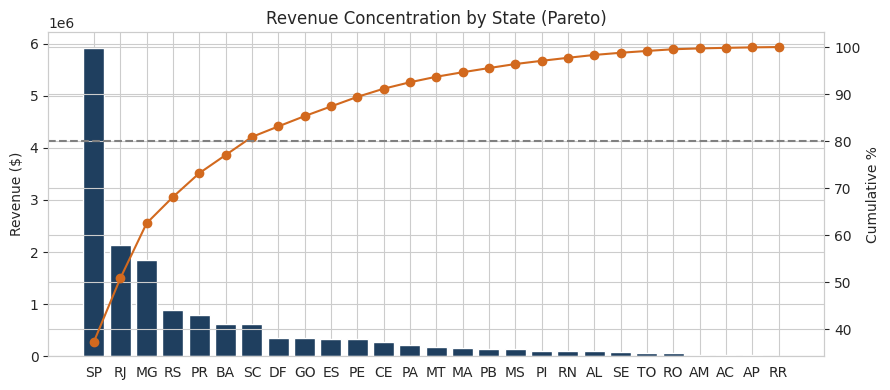

In [0]:
print("\n--- D4. Revenue Concentration by State (Pareto) ---")
state_rev = base.groupby("customer_state")["order_revenue"].sum().sort_values(ascending=False)
cum_pct = (state_rev.cumsum() / state_rev.sum() * 100)
print(pd.DataFrame({"revenue": state_rev, "cumulative_pct": cum_pct}).head(8))

fig, ax1 = plt.subplots(figsize=(9,4))
ax1.bar(state_rev.index, state_rev.values, color="#1F3F5F")
ax1.set_ylabel("Revenue ($)")
ax2 = ax1.twinx()
ax2.plot(state_rev.index, cum_pct.values, color="#D2691E", marker="o")
ax2.set_ylabel("Cumulative %")
ax2.axhline(80, color="gray", linestyle="--")
plt.title("Revenue Concentration by State (Pareto)")
plt.tight_layout()
plt.show()

**Finding:** SP alone accounts for **37.4%** of total revenue; the top 7 states account for **80.9%** - a textbook 80/20 concentration pattern.

**Marketing implication:** Geographic marketing spend should heavily weight SP, RJ, and MG rather than spreading evenly across all 27 states - the long tail of states contributes very little.


### D5. SEASONALITY / HOLIDAY SPIKE 

In [0]:
print("\n--- D5. Seasonality: Orders by Month (rolling avg comparison) ---")
monthly_orders = base.groupby("order_month")["order_id"].nunique()
rolling_avg = monthly_orders.rolling(3, center=True).mean()
spike_check = pd.DataFrame({"orders": monthly_orders, "rolling_3mo_avg": rolling_avg})
spike_check["pct_above_avg"] = (spike_check["orders"] / spike_check["rolling_3mo_avg"] - 1) * 100
print(spike_check.sort_values("pct_above_avg", ascending=False).head(5))



--- D5. Seasonality: Orders by Month (rolling avg comparison) ---
             orders  rolling_3mo_avg  pct_above_avg
order_month                                        
2016-10         324       109.666667     195.440729
2017-11        7544      5949.333333      26.804124
2017-05        3700      3116.333333      18.729276
2017-03        2682      2288.666667      17.186135
2018-01        7269      6556.666667      10.864260


**Finding:** November 2017 had a real **+26.8% increase** compared with its rolling average, which shows a clear Black Friday effect. The **+195% increase in October 2016** is misleading because the business was still new and had a very small number of orders (around 110 orders per month). So, this increase is not strong evidence of seasonality.

**Marketing implication:** The November 2017 result can be used to support a regular Black Friday campaign. The October 2016 result should not be used as evidence of seasonality because it was affected by the low number of orders when the business had just started.


### 3.6 Voucher Usage vs Repeat Purchase Rate

--- Voucher Usage vs Repeat Purchase Rate ---
used_voucher
False    3.011519
True     9.014810
Name: repeat_rate_pct, dtype: float64


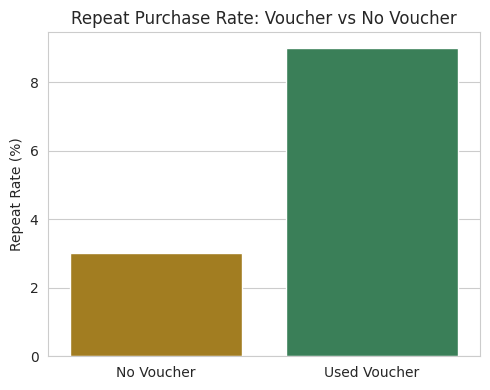

In [0]:
print("--- Voucher Usage vs Repeat Purchase Rate ---")
cust_payment = base.groupby("customer_unique_id").agg(used_voucher=("payment_type", lambda x: (x=="voucher").any()), order_count=("order_id","nunique"))
cust_payment["is_repeat"] = cust_payment["order_count"] > 1
vr = cust_payment.groupby("used_voucher")["is_repeat"].mean() * 100
print(vr.rename("repeat_rate_pct"))
plt.figure(figsize=(5,4))
sns.barplot(x=["No Voucher","Used Voucher"], y=vr.values, palette=["#B8860B","#2E8B57"])
plt.title("Repeat Purchase Rate: Voucher vs No Voucher")
plt.ylabel("Repeat Rate (%)")
plt.tight_layout()
plt.show()

**Finding:** Customers who used a voucher at least once had a **9.0% repeat purchase rate**, compared with **3.0% for customers who did not use vouchers**. This is a 3x difference and is one of the strongest relationships found in the analysis.

**Caveat:** This shows a relationship, but it does not prove that vouchers caused customers to come back. It could also be that customers who are already more interested in the business are more likely to use vouchers and make another purchase.

**Marketing implication:** This is worth testing with a small experiment. The company could offer vouchers to a group of one-time customers and compare their repeat purchase rate with a similar group that does not receive vouchers. This would help determine whether vouchers actually increase repeat purchases.


### 3.7 Correlation Matrix - Order & Satisfaction Metrics

--- Correlation Matrix ---
                     order_revenue  ...  review_score
order_revenue                 1.00  ...         -0.04
total_freight                 0.49  ...         -0.09
n_items                       0.19  ...         -0.12
max_installments              0.32  ...         -0.03
delivery_delay_days          -0.02  ...         -0.27
review_score                 -0.04  ...          1.00

[6 rows x 6 columns]


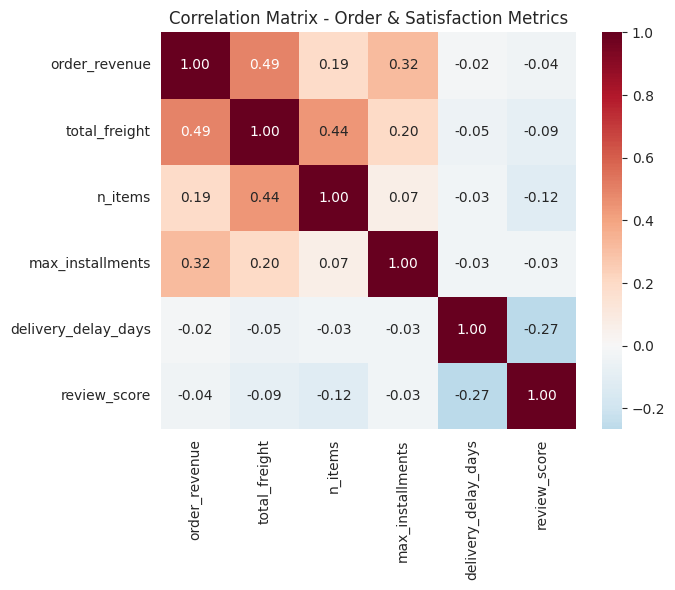

In [0]:
print("--- Correlation Matrix ---")
corr_cols = ["order_revenue","total_freight","n_items","max_installments","delivery_delay_days","review_score"]
corr_matrix = base[corr_cols].dropna().corr()
print(corr_matrix.round(2))
plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Matrix - Order & Satisfaction Metrics")
plt.tight_layout()
plt.show()

**Finding:** delivery_delay_days has the strongest relationship with review_score, with a correlation of **-0.27**. This means that as delivery delays increase, review scores tend to decrease. n_items also has a small negative correlation of **-0.12**, meaning orders with more items tend to have slightly lower review scores. This could be because larger orders have a higher chance of having some issue with one of the items.

**Marketing implication:** Delivery reliability appears to be the main factor linked to customer satisfaction in this analysis. This supports the finding from Section 2.1 and shows that improving on-time delivery could be an important area to focus on.


--- K-Means Customer Clustering (RFM-based) ---
         customers  avg_recency  avg_frequency  avg_monetary
cluster                                                     
0            37996   390.671808       1.000000    132.320069
1            51767   130.239033       1.000000    133.656994
2             2684   245.021982       1.003353   1114.904026
3             2973   221.612176       2.115372    143.906703


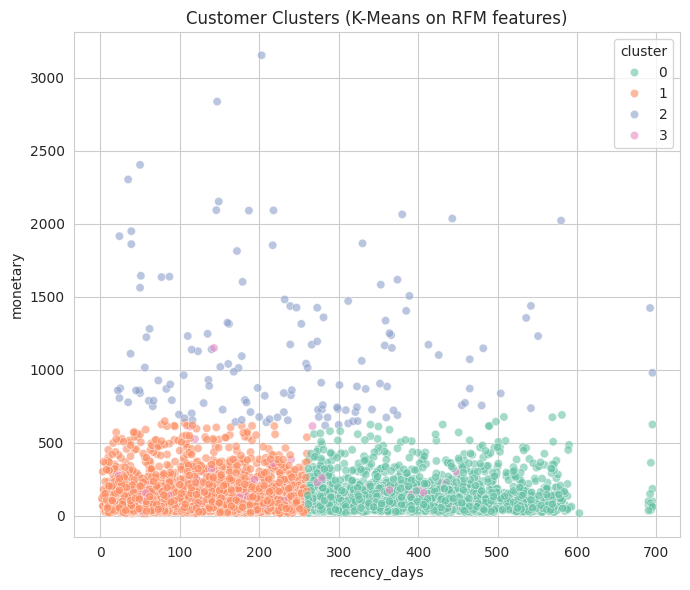

In [0]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
print("--- K-Means Customer Clustering (RFM-based) ---")
snapshot_date = base["order_purchase_timestamp"].max()
rfm_raw = base.groupby("customer_unique_id").agg(recency_days=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),    frequency=("order_id","nunique"), monetary=("order_revenue","mean")).dropna()
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_raw)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_raw["cluster"] = kmeans.fit_predict(rfm_scaled)
cluster_summary = rfm_raw.groupby("cluster").agg(customers=("recency_days","count"), avg_recency=("recency_days","mean"),avg_frequency=("frequency","mean"), avg_monetary=("monetary","mean"))
print(cluster_summary)
plt.figure(figsize=(7,6))
sns.scatterplot(data=rfm_raw.sample(min(5000,len(rfm_raw))), x="recency_days", y="monetary", hue="cluster", palette="Set2", alpha=0.6)
plt.title("Customer Clusters (K-Means on RFM features)")
plt.tight_layout()
plt.show()

**Finding:** K-Means found an important customer group that was not clearly visible in the manual RFM analysis. **Cluster 2 has 2,684 customers who made only one purchase but had a high average order value of R$1,115.** These customers never came back. In the manual RFM analysis, they were mixed into the “Regular” or “New” groups because purchase frequency had a strong influence on the scoring. K-Means looks at all three RFM factors together, so it was able to identify this high-value group more clearly.

**Marketing implication:** This group could be a good target for a win-back campaign because it is a smaller group of customers who have already shown that they are willing to spend more. The company could use targeted offers or reminders to encourage them to make another purchase, instead of sending the same campaign to the much larger **37,996-customer Dormant group**, which has a much lower average order value of **R$132**.
